* ## Angélica Vanegas C.C 1000290572

### Potential and Electric field from a capacitor

To find the potential generated by a capacitor  of two rectangular plates of width $d$ is challenging (see figure). In general, we can do some approximation based in infinite plates to get an intuition of the solution. In this approximation we have:

\begin{equation}
|\vec{E}| \approx \dfrac{\sigma}{2\epsilon_0}, \text{inside}\,,
\end{equation}
\begin{equation}
|\vec{E}| \approx 0, \text{  outside}\,.
\end{equation}

However, we know that the potential $\phi$ and the electric field $\vec{E}$ fulfill the Laplace's equation $\nabla^2\phi = 0$ in the region around the plates (where $\rho=0$).

* Use finite differences to solve the Laplace's equation in the neigborhood of this capacitor. Use the imshow or the contour function to plot the potential.

* Compute numerically (use finite difference method) the electric field.

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/Laplace_df_capacitor.png" width="500" height="300" />

# Solución

Para esto vamos a tomar una malla que contenga las placas con las siguientes condiciones de frontera:

Placa izquierda: $\phi = \frac{+V_O}{2}$ en $x = a$ y $y = C + l$

Placa derecha: $\phi = \frac{-V_O}{2}$ en $x = b$ y $y = C + l$

La malla va recorer el espacio alrededor de las placas, las placas y el espacio dentro de ellas.


In [ ]:
#@title Implementación del método

import numpy as np
import matplotlib.pyplot as plt

# Mallita
Nx, Ny = 80, 100
V = np.zeros((Ny, Nx))

# Parámetros geométricos

V0 = 100        # valor del potencial
a = 25          # distancia placa izquierda
b = 50          # distancia placa derecha
c = 40          # base placas
l = 20          # altura placas
ancho = 4       # ancho de las placas

# Definir las condiciones de nuestro potencial en las placas

V[c:c+l, a:a+ancho] = V0/2
V[c:c+l, b:b+ancho] = -V0/2

# Como el método iterativo va a recorrer las placas también debido a la forma
#de la malla, entonces debemos exigirle que no cambie estos valores ya dados

V2 = np.zeros_like(V, dtype=bool)   #una malla de las dimensiones de V pero de tipo bool
V2[c:c+l, a:a+ancho] = True         #no cambia su valor
V2[c:c+l, b:b+ancho] = True

Niter = 500

for k in range(Niter):
    Vol = V.copy()

    for i in range(1, Ny-1):
        for j in range(1, Nx-1):
            if not V2[i,j]:
                V[i,j] = 0.25*(
                    Vol[i+1,j] + Vol[i-1,j] +
                    Vol[i,j+1] + Vol[i,j-1]
                )


Para graficar con imshow:

https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html

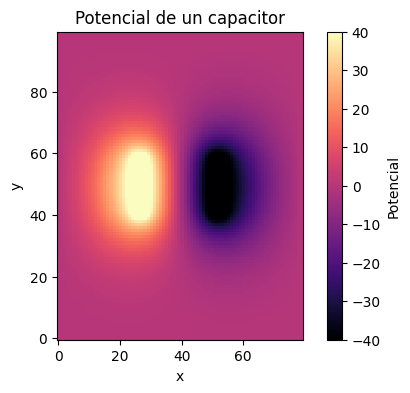

In [ ]:
#@title Grafiquita

plt.figure(figsize=(6,4))
plt.imshow(V, origin="lower", cmap="magma", vmin=-40, vmax=40)
plt.colorbar(label="Potencial")
plt.title("Potencial de un capacitor")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

Sabemos que: $E = − ∇ V$.Entonces para calcular el campo elétrico vamos a usar la función np.gradient()

https://numpy.org/devdocs/reference/generated/numpy.gradient.html


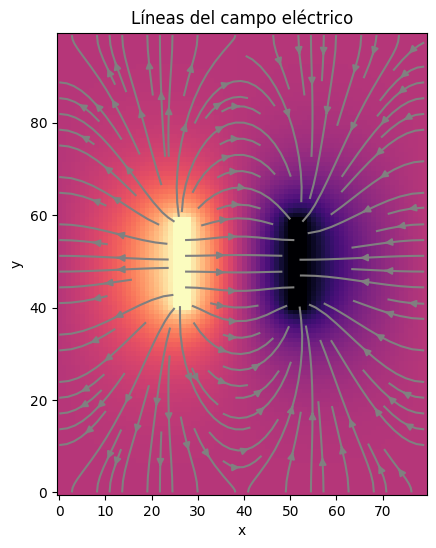

In [50]:
#@title Gráfiquitas del campo elétrico

Ey, Ex = np.gradient(-V)
x = np.arange(Nx)
y = np.arange(Ny)

plt.figure(figsize=(8,6))
plt.imshow(V, origin="lower", cmap="magma")
plt.streamplot(x, y, Ex, Ey, density = 1, color = "gray")
plt.title("Líneas del campo eléctrico")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


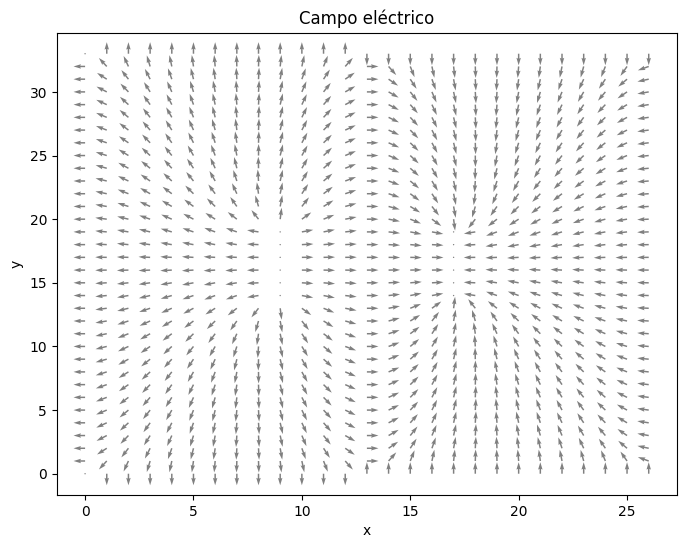

In [ ]:
# Magnitud del campo
Emag = np.sqrt(Ex**2 + Ey**2)

# Normalización
Exn = Ex / (Emag + 1e-12)  #se asegura de que no hayan valores t.q la división sea infinita
Eyn = Ey / (Emag + 1e-12)

plt.figure(figsize=(8,6))
plt.quiver(Exn[::3, ::3], Eyn[::3, ::3], color="gray")
plt.title("Campo eléctrico")
plt.xlabel("x")
plt.ylabel("y")
plt.show()